In [1]:
# Cell 1: Load data, GA results, and run RF tuning for
#         Baseline + GA top-5 USING THE OLD TUNING FUNCTION

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from IPython.display import display

from scipy.stats import randint
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import recall_score
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier
import shap
# ------------------------------------
# 1) Load train / test data
# ------------------------------------

# Load non-zero (NZ) feature matrices generated earlier
# These CSVs are stored under data/ED_preproc_single_split
X_train = pd.read_csv("../data/ED_preproc_single_split/X_train_sel.csv")
X_test  = pd.read_csv("../data/ED_preproc_single_split/X_test_sel.csv")

# Load labels corresponding to the same single train/test split
y_train = pd.read_csv("../data/ED_preproc_single_split/y_train.csv").squeeze("columns")
y_test  = pd.read_csv("../data/ED_preproc_single_split/y_test.csv").squeeze("columns")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

y_np = y_train.to_numpy().ravel()
y_te = y_test.to_numpy().ravel()

# ------------------------------------
# 2) Load GA results (ga_best.npz)
# ------------------------------------
ga_npz = np.load(
    "../data/ED_preproc_single_split/ga_best_ed.npz",
    allow_pickle=True
)
print("\n[INFO] npz keys:", ga_npz.files)

top_scores = np.asarray(ga_npz["top_scores"], dtype=float)

# Build top_cols_all from npz (handle both 'top_masks' and 'top_cols')
if "top_masks" in ga_npz.files:
    raw_masks = list(ga_npz["top_masks"])  # list of boolean arrays
    top_cols_all = [
        np.flatnonzero(np.asarray(m, dtype=bool)).astype(int)
        for m in raw_masks
    ]
else:
    raw_cols = list(ga_npz["top_cols"])    # list of index arrays
    top_cols_all = [np.asarray(c, dtype=int) for c in raw_cols]

n_feat_total = X_train.shape[1]
print(f"[INFO] Loaded {len(top_cols_all)} GA feature sets.")

# ------------------------------------
# 3) Define PARAM_DIST and old tuning settings
#    (EXACTLY as in your previous test code)
# ------------------------------------
PARAM_DIST = {
    "n_estimators": randint(100, 650),
    "max_depth": [None, 8, 12],
    "max_features": ["sqrt", "log2", 0.3, 0.5, 0.7],
    "min_samples_split": randint(2, 20),
    "min_samples_leaf": randint(1, 8),
    "bootstrap": [True],
    "max_samples": [None, 0.6, 0.8, 1.0],
    "class_weight": [None, "balanced"],
    "criterion": ["gini", "entropy"],
}

STAGE1_N_ITER = globals().get("STAGE1_N_ITER", 80)  # keep 80 if defined, same as before
RANDOM_STATE  = 42

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=2042)

def tune_rf_for_features(feature_idx, label):
    """
    RF hyperparameter tuning on a given feature subset using the EXACT same
    RandomizedSearchCV settings as before (so results are comparable).
    """
    X_sub = X_train.iloc[:, feature_idx].to_numpy()

    rs = RandomizedSearchCV(
        estimator=RandomForestClassifier(random_state=2042, n_jobs=-1),
        param_distributions=PARAM_DIST,
        n_iter=STAGE1_N_ITER,
        scoring="roc_auc",
        cv=cv5,
        n_jobs=-1,
        random_state=2042,
        verbose=0
    )
    rs.fit(X_sub, y_np)

    best_params = dict(rs.best_params_)
    # Clean up for direct RF instantiation
    best_params.pop("random_state", None)
    best_params.pop("n_jobs", None)
    if best_params.get("bootstrap") is False:
        best_params.pop("max_samples", None)

    print(f"[CV] {label} best AUC = {rs.best_score_:.4f}")
    print(f"[CV] {label} best params = {best_params}")
    return best_params, float(rs.best_score_)

# ------------------------------------
# 4) Build feature_sets: Baseline + GA top-5 (by GA score)
# ------------------------------------
N_TOP_GA = 5

# sort GA solutions by GA score (descending)
sorted_idx = np.argsort(top_scores)[::-1]
top_idx    = sorted_idx[:N_TOP_GA]

feature_sets = []

# (0) Baseline: all 84 features
all_cols = np.arange(n_feat_total, dtype=int)
feature_sets.append({
    "name": "Baseline (ALL wrapper)",
    "cols": all_cols,
})

# (1) GA top-5 feature subsets
for rank, idx in enumerate(top_idx, 1):
    cols = np.asarray(top_cols_all[idx], dtype=int)
    feature_sets.append({
        "name": f"GA-{rank} (idx={idx})",
        "cols": cols,
        "ga_score": float(top_scores[idx]),
    })

print("\n[INFO] Feature sets to tune (Baseline + GA top-5):")
for fs in feature_sets:
    print(f"  {fs['name']}: d={len(fs['cols'])}")

# ------------------------------------
# 5) Run tuning for each feature set USING THE SAME FUNCTION
# ------------------------------------
for fs in feature_sets:
    params, cv_auc = tune_rf_for_features(fs["cols"], fs["name"])
    fs["best_params"] = params
    fs["cv_auc"]      = cv_auc


c:\Users\junse\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


X_train: (41, 37)
X_test : (18, 37)
y_train: (41,)
y_test : (18,)


FileNotFoundError: [Errno 2] No such file or directory: '../data/ED_preproc_single_split/ga_best_ed.npz'

[Train CV ROC] Baseline (ALL wrapper): AUC 0.7889 ± 0.1261
[Train CV ROC] GA-1 (idx=0): AUC 0.8222 ± 0.1507
[Train CV ROC] GA-2 (idx=1): AUC 0.7867 ± 0.1543
[Train CV ROC] GA-3 (idx=2): AUC 0.8022 ± 0.1431
[Train CV ROC] GA-4 (idx=3): AUC 0.7822 ± 0.1220
[Train CV ROC] GA-5 (idx=4): AUC 0.8667 ± 0.1633


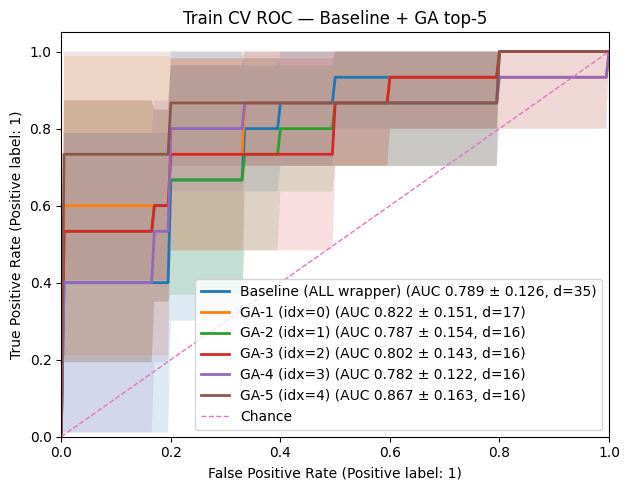

In [ ]:
# Cell 2: Train CV ROC for Baseline + GA top-5
#         (NO NEW TUNING; use fs["best_params"] from Cell 1)

FPR_GRID = np.linspace(0.0, 1.0, 201)

def cv_roc_with_fixed_params(X, y, params, label, cv):
    """
    Given fixed RF params, compute mean ± std ROC curves over the given CV object.
    """
    tprs = []
    aucs = []

    for tr_idx, va_idx in cv.split(X, y):
        clf = RandomForestClassifier(
            random_state=2042,
            n_jobs=-1,
            **params
        )
        clf.fit(X[tr_idx], y[tr_idx])
        prob = clf.predict_proba(X[va_idx])[:, 1]

        fpr, tpr, _ = roc_curve(y[va_idx], prob)
        auc_fold = roc_auc_score(y[va_idx], prob)
        aucs.append(auc_fold)

        tpr_i = np.interp(FPR_GRID, fpr, tpr, left=0.0, right=1.0)
        tpr_i[0]  = 0.0
        tpr_i[-1] = 1.0
        tprs.append(tpr_i)

    tprs     = np.vstack(tprs)
    mean_tpr = tprs.mean(axis=0)
    std_tpr  = tprs.std(axis=0)
    auc_mean = float(np.mean(aucs))
    auc_std  = float(np.std(aucs))

    print(f"[Train CV ROC] {label}: AUC {auc_mean:.4f} ± {auc_std:.4f}")
    return mean_tpr, std_tpr, auc_mean, auc_std

plt.figure(figsize=(6.4, 5.0))

for fs in feature_sets:
    cols   = np.asarray(fs["cols"], dtype=int)
    params = dict(fs["best_params"])

    X_sub = X_train.iloc[:, cols].to_numpy()

    mean_tpr, std_tpr, auc_mean, auc_std = cv_roc_with_fixed_params(
        X_sub, y_np, params, fs["name"], cv5
    )

    fs["cv_auc_mean"] = auc_mean
    fs["cv_auc_std"]  = auc_std

    label = f"{fs['name']} (AUC {auc_mean:.3f} ± {auc_std:.3f}, d={len(cols)})"
    plt.plot(FPR_GRID, mean_tpr, lw=2, label=label)
    plt.fill_between(
        FPR_GRID,
        np.maximum(mean_tpr - std_tpr, 0.0),
        np.minimum(mean_tpr + std_tpr, 1.0),
        alpha=0.15,
    )

plt.plot([0, 1], [0, 1], "--", lw=1, label="Chance")
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.xlabel("False Positive Rate (Positive label: 1)")
plt.ylabel("True Positive Rate (Positive label: 1)")
plt.title("Train CV ROC — Baseline + GA top-5")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


In [ ]:
# ------------------------------------------------
# 1) Collect only GA-based feature sets (exclude Baseline)
# ------------------------------------------------
ga_feature_sets = [fs for fs in feature_sets if fs["name"].startswith("GA-")]

if len(ga_feature_sets) == 0:
    raise ValueError("No GA feature sets found. Make sure feature_sets contains entries named 'GA-1', 'GA-2', ...")

# Each GA subset already has:
#   - fs["cv_auc_mean"]: mean AUC over CV folds (from Cell 2)
#   - fs["cv_auc_std"] : std  AUC over CV folds (from Cell 2)
# We now summarize:
#   (1) per-subset CV AUC statistics in a table
#   (2) across-subset AUC stability: how much these per-subset means vary
#       -> treat each GA run's cv_auc_mean as one observation
#          and compute mean / std across runs.

subset_names = [fs["name"] for fs in ga_feature_sets]
subset_sizes = [len(fs["cols"]) for fs in ga_feature_sets]
ga_auc_means = np.array([fs["cv_auc_mean"] for fs in ga_feature_sets], dtype=float)
ga_auc_stds  = np.array([fs["cv_auc_std"]  for fs in ga_feature_sets], dtype=float)

# --------------------------------------------
# Table 1: per-GA-subset CV AUC summary
# --------------------------------------------
auc_table = pd.DataFrame({
    "subset": subset_names,
    "n_features": subset_sizes,
    "cv_auc_mean_over_folds": ga_auc_means,
    "cv_auc_std_over_folds": ga_auc_stds,
})
auc_table = auc_table.sort_values("subset").reset_index(drop=True)

# Across-subset AUC stability:
#   - ga_auc_means: length = n_GA_runs (e.g., 5)
#   - mean: average AUC across GA runs
#   - std : how much the *average* AUC changes between GA runs
auc_across_mean = float(ga_auc_means.mean())
auc_across_std  = float(ga_auc_means.std(ddof=1))  # sample std across GA subsets

auc_stability_summary = pd.DataFrame({
    "metric": ["across_subsets_mean_AUC", "across_subsets_std_AUC"],
    "value":  [auc_across_mean,            auc_across_std]
})

# --------------------------------------------
# 2) Jaccard similarity between GA subsets
# --------------------------------------------
def jaccard_similarity(indices_a, indices_b):
    """
    Compute Jaccard similarity between two index sets:
      J(A,B) = |A ∩ B| / |A ∪ B|
    """
    set_a = set(indices_a)
    set_b = set(indices_b)
    union = set_a | set_b
    if not union:
        return 0.0
    inter = set_a & set_b
    return len(inter) / len(union)

n_ga   = len(ga_feature_sets)
labels = [fs["name"] for fs in ga_feature_sets]

jacc_matrix = np.zeros((n_ga, n_ga), dtype=float)

# Full Jaccard matrix (symmetric, diagonal = 1)
for i in range(n_ga):
    for j in range(n_ga):
        jacc_matrix[i, j] = jaccard_similarity(
            ga_feature_sets[i]["cols"],
            ga_feature_sets[j]["cols"]
        )

# DataFrame for a clean matrix view
jacc_df = pd.DataFrame(jacc_matrix, index=labels, columns=labels)

# Upper-triangular values (i < j) for summary mean ± std
upper_vals = [
    jacc_matrix[i, j]
    for i in range(n_ga)
    for j in range(i + 1, n_ga)
]

jacc_mean = float(np.mean(upper_vals)) if upper_vals else 0.0
jacc_std  = float(np.std(upper_vals, ddof=1)) if len(upper_vals) > 1 else 0.0

jacc_summary = pd.DataFrame({
    "metric": ["mean_Jaccard_over_pairs", "std_Jaccard_over_pairs"],
    "value":  [jacc_mean,                  jacc_std]
})


# --------------------------------------------
# 3) Sensitivity comparison: mean recall at 0.5
# --------------------------------------------
def cv_sensitivity_at_threshold(X, y, params, cv, threshold=0.5):
    """
    Compute mean ± std sensitivity (recall for positive class)
    across CV folds, at a fixed probability threshold.
    """
    recalls = []

    for tr_idx, va_idx in cv.split(X, y):
        clf = RandomForestClassifier(
            random_state=2042,
            n_jobs=-1,
            **params
        )
        clf.fit(X[tr_idx], y[tr_idx])
        prob = clf.predict_proba(X[va_idx])[:, 1]

        y_pred = (prob >= threshold).astype(int)
        rec = recall_score(y[va_idx], y_pred, pos_label=1)
        recalls.append(rec)

    recalls = np.array(recalls, dtype=float)
    return float(recalls.mean()), float(recalls.std(ddof=1))

sens_rows = []
for fs in ga_feature_sets:
    cols   = np.asarray(fs["cols"], dtype=int)
    params = dict(fs["best_params"])
    X_sub  = X_train.iloc[:, cols].to_numpy()
    y_sub  = y_np  # same labels as before

    sens_mean, sens_std = cv_sensitivity_at_threshold(
        X_sub, y_sub, params, cv5, threshold=0.5
    )

    sens_rows.append({
        "subset": fs["name"],
        "n_features": len(cols),
        "cv_auc_mean_over_folds": fs["cv_auc_mean"],
        "cv_auc_std_over_folds":  fs["cv_auc_std"],
        "sensitivity_mean_at_0.5": sens_mean,
        "sensitivity_std_at_0.5":  sens_std,
    })

sens_table = pd.DataFrame(sens_rows).sort_values("subset").reset_index(drop=True)


# --------------------------------------------
# 4) Display all tables nicely
# --------------------------------------------
# (You can remove .round(...) if you want full precision.)
display(auc_table.round(3))             # Table: per-GA-subset AUC
display(auc_stability_summary.round(4)) # Table: across-subset AUC stability
display(jacc_df.round(3))               # Table: Jaccard matrix
display(jacc_summary.round(4))          # Table: Jaccard mean/std
display(sens_table.round(3))            # Table: AUC + sensitivity per GA subset


,subset,n_features,cv_auc_mean_over_folds,cv_auc_std_over_folds
0,GA-1 (idx=0),17,0.822,0.151
1,GA-2 (idx=1),16,0.787,0.154
2,GA-3 (idx=2),16,0.802,0.143
3,GA-4 (idx=3),16,0.782,0.122
4,GA-5 (idx=4),16,0.867,0.163


,metric,value
0,across_subsets_mean_AUC,0.8120
1,across_subsets_std_AUC,0.0343


,GA-1 (idx=0),GA-2 (idx=1),GA-3 (idx=2),GA-4 (idx=3),GA-5 (idx=4)
GA-1 (idx=0),1.000,0.435,0.375,0.375,0.435
GA-2 (idx=1),0.435,1.000,0.333,0.280,0.455
GA-3 (idx=2),0.375,0.333,1.000,0.455,0.231
GA-4 (idx=3),0.375,0.280,0.455,1.000,0.333
GA-5 (idx=4),0.435,0.455,0.231,0.333,1.000


,metric,value
0,mean_Jaccard_over_pairs,0.3706
1,std_Jaccard_over_pairs,0.0767


,subset,n_features,cv_auc_mean_over_folds,cv_auc_std_over_folds,sensitivity_mean_at_0.5,sensitivity_std_at_0.5
0,GA-1 (idx=0),17,0.822,0.151,0.667,0.333
1,GA-2 (idx=1),16,0.787,0.154,0.600,0.365
2,GA-3 (idx=2),16,0.802,0.143,0.467,0.183
3,GA-4 (idx=3),16,0.782,0.122,0.467,0.380
4,GA-5 (idx=4),16,0.867,0.163,0.667,0.333


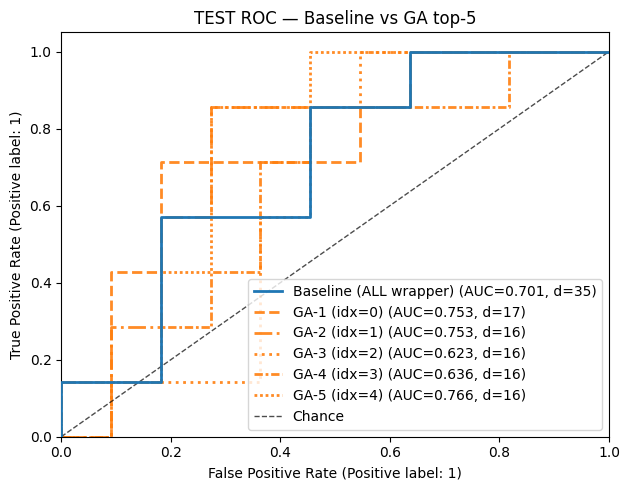


===== SUMMARY: Baseline + GA top-5 (CV & TEST) =====
                     name  n_features  cv_auc_best  cv_auc_mean  cv_auc_std  \
0  Baseline (ALL wrapper)          35     0.788889     0.788889    0.126100   
1            GA-1 (idx=0)          17     0.822222     0.822222    0.150718   
2            GA-2 (idx=1)          16     0.786667     0.786667    0.154344   
3            GA-3 (idx=2)          16     0.802222     0.802222    0.143053   
4            GA-4 (idx=3)          16     0.782222     0.782222    0.122040   
5            GA-5 (idx=4)          16     0.866667     0.866667    0.163299   

   test_auc  
0  0.701299  
1  0.753247  
2  0.753247  
3  0.623377  
4  0.636364  
5  0.766234  


In [ ]:
# Cell 3: Final train on FULL TRAIN + TEST ROC (Baseline + GA top-5)

plt.figure(figsize=(6.4, 5.0))

test_rows = []

# Colors: one for Baseline, one shared color for all GA subsets
COLOR_BASELINE = "tab:blue"   # unique color for Baseline
COLOR_GA       = "tab:orange" # shared color for all GA feature sets

# Different linestyles for GA-1 ... GA-5 (same color, different pattern)
GA_LINESTYLES = [
    "--",              # GA-1
    "-.",              # GA-2
    ":",               # GA-3
    (0, (3, 1, 1, 1)), # GA-4 (custom dash pattern)
    (0, (1, 1)),       # GA-5 (dense dash)
]

ga_idx = 0  # index to assign linestyles for GA subsets

for fs in feature_sets:
    cols   = np.asarray(fs["cols"], dtype=int)
    params = dict(fs["best_params"])

    Xtr_sub = X_train.iloc[:, cols].to_numpy()
    Xte_sub = X_test.iloc[:,  cols].to_numpy()

    clf = RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        **params
    )
    clf.fit(Xtr_sub, y_np)
    prob_te = clf.predict_proba(Xte_sub)[:, 1]

    auc_te = roc_auc_score(y_te, prob_te)
    fpr, tpr, _ = roc_curve(y_te, prob_te)

    # Style for Baseline vs GA subsets
    if fs["name"].lower().startswith("baseline"):
        # Baseline: thick, solid, fully opaque, highest z-order
        curve_color = COLOR_BASELINE
        line_style  = "-"
        alpha       = 1.0
        z           = 3
    else:
        # GA subsets: same color, different linestyles, slightly thinner
        curve_color = COLOR_GA
        # Safeguard: if more GA sets than styles, wrap around
        line_style  = GA_LINESTYLES[min(ga_idx, len(GA_LINESTYLES) - 1)]
        alpha       = 0.9
        z           = 2
        ga_idx += 1

    label = f"{fs['name']} (AUC={auc_te:.3f}, d={len(cols)})"

    plt.plot(
        fpr,
        tpr,
        lw=2,
        label=label,
        color=curve_color,
        linestyle=line_style,
        alpha=alpha,
        zorder=z,
    )

    test_rows.append({
        "name": fs["name"],
        "n_features": int(len(cols)),
        "cv_auc_mean": float(fs.get("cv_auc_mean", np.nan)),
        "cv_auc_std":  float(fs.get("cv_auc_std",  np.nan)),
        "cv_auc_best": float(fs.get("cv_auc", np.nan)),  # from tuning
        "test_auc":    float(auc_te),
    })

# Chance line
plt.plot([0, 1], [0, 1], "--", lw=1, label="Chance", color="black", alpha=0.7)

plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.xlabel("False Positive Rate (Positive label: 1)")
plt.ylabel("True Positive Rate (Positive label: 1)")
plt.title("TEST ROC — Baseline vs GA top-5")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

results_df = pd.DataFrame(test_rows)
print("\n===== SUMMARY: Baseline + GA top-5 (CV & TEST) =====")
print(results_df[["name", "n_features", "cv_auc_best", "cv_auc_mean", "cv_auc_std", "test_auc"]])


In [ ]:
# 0) GA-only feature sets (exclude Baseline)
ga_feature_sets = [fs for fs in feature_sets if fs["name"].startswith("GA-")]
if len(ga_feature_sets) == 0:
    raise ValueError("No GA feature sets found in feature_sets (expected names starting with 'GA-').")

# 1) Lookup tables from auc_table / sens_table
#    - auc_table columns: "subset", "cv_auc_mean_over_folds", "cv_auc_std_over_folds"
#    - sens_table columns: "subset", "sensitivity_mean_at_0.5", "sensitivity_std_at_0.5"
auc_lookup  = {row["subset"]: row for _, row in auc_table.iterrows()}
sens_lookup = {row["subset"]: row for _, row in sens_table.iterrows()}

# 2) Attach CV AUC / sensitivity stats into each GA feature set dict
for fs in ga_feature_sets:
    name = fs["name"]

    # ---- CV AUC mean / std (from nested CV table) ----
    auc_row = auc_lookup.get(name, None)
    if auc_row is not None:
        fs["cv_auc_mean"] = float(auc_row["cv_auc_mean_over_folds"])
        fs["cv_auc_std"]  = float(auc_row["cv_auc_std_over_folds"])
    else:
        fs["cv_auc_mean"] = float("nan")
        fs["cv_auc_std"]  = float("nan")

    # ---- Sensitivity mean / std at threshold 0.5 ----
    sens_row = sens_lookup.get(name, None)
    if sens_row is not None:
        fs["sensitivity_mean_at_0.5"] = float(sens_row["sensitivity_mean_at_0.5"])
        fs["sensitivity_std_at_0.5"]  = float(sens_row["sensitivity_std_at_0.5"])
    else:
        fs["sensitivity_mean_at_0.5"] = float("nan")
        fs["sensitivity_std_at_0.5"]  = float("nan")

# 3) Filter candidates by sensitivity >= 0.8
SENS_MIN = 0.60
eligible = [
    fs for fs in ga_feature_sets
    if np.isfinite(fs.get("sensitivity_mean_at_0.5", np.nan))
    and fs["sensitivity_mean_at_0.5"] >= SENS_MIN
    and np.isfinite(fs.get("cv_auc_mean", np.nan))
]

if len(eligible) == 0:
    raise ValueError(f"No GA subsets meet sensitivity >= {SENS_MIN:.2f}. Consider lowering SENS_MIN or checking sens_table.")

# 4) Choose the subset whose CV train AUC is closest to the median among eligible candidates
eligible_cv_means = np.array([fs["cv_auc_mean"] for fs in eligible], dtype=float)
target_median = float(np.median(eligible_cv_means))

# Primary key: abs distance to median
# Tiebreakers: lower AUC std, then fewer features (optional but reasonable)
best_ga = min(
    eligible,
    key=lambda fs: (
        abs(fs["cv_auc_mean"] - target_median),
        fs.get("cv_auc_std", np.inf),
        len(fs["cols"]),
    )
)

# 5) Print summary
print("[INFO] Eligible GA candidates (sensitivity >= {:.2f}):".format(SENS_MIN))
for fs in sorted(eligible, key=lambda x: x["cv_auc_mean"]):
    print(
        f"  {fs['name']}: d={len(fs['cols']):2d}, "
        f"CV AUC={fs['cv_auc_mean']:.4f} ± {fs.get('cv_auc_std', float('nan')):.4f}, "
        f"sens@0.5={fs['sensitivity_mean_at_0.5']:.4f}"
    )

print("\n[INFO] Median CV AUC among eligible:", target_median)
print("[INFO] Chosen for SHAP (closest to median CV AUC):")
print(" name      :", best_ga["name"])
print(" n_features:", len(best_ga["cols"]))
print(" CV AUC    :", best_ga["cv_auc_mean"], "±", best_ga.get("cv_auc_std", float("nan")))
print(" sens@0.5  :", best_ga.get("sensitivity_mean_at_0.5", float("nan")))

[INFO] Eligible GA candidates (sensitivity >= 0.60):
  GA-2 (idx=1): d=16, CV AUC=0.7867 ± 0.1543, sens@0.5=0.6000
  GA-1 (idx=0): d=17, CV AUC=0.8222 ± 0.1507, sens@0.5=0.6667
  GA-5 (idx=4): d=16, CV AUC=0.8667 ± 0.1633, sens@0.5=0.6667

[INFO] Median CV AUC among eligible: 0.8222222222222222
[INFO] Chosen for SHAP (closest to median CV AUC):
 name      : GA-1 (idx=0)
 n_features: 17
 CV AUC    : 0.8222222222222222 ± 0.15071844406945042
 sens@0.5  : 0.6666666666666666


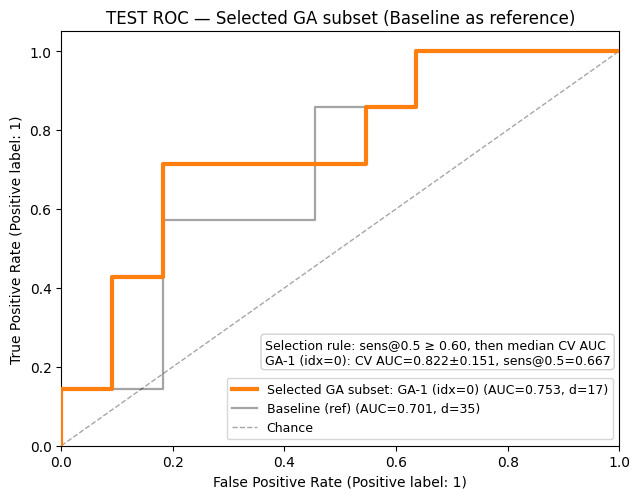


===== SUMMARY: Selected GA + Baseline (CV & TEST) =====
                     name  n_features  cv_auc_best  cv_auc_mean  cv_auc_std  \
0            GA-1 (idx=0)          17     0.822222     0.822222    0.150718   
1  Baseline (ALL wrapper)          35     0.788889     0.788889    0.126100   

   test_auc  
0  0.753247  
1  0.701299  


In [ ]:
# Cell: TEST ROC (Selected GA emphasized, Baseline as reference) + selection rule above legend

plt.figure(figsize=(6.6, 5.1))

test_rows_2 = []

# 1) Pick Baseline and the chosen GA subset
baseline_fs = None
for fs in feature_sets:
    if fs["name"].lower().startswith("baseline"):
        baseline_fs = fs
        break
if baseline_fs is None:
    raise ValueError("Baseline feature set not found in feature_sets (expected name starting with 'Baseline').")

plot_sets = [best_ga, baseline_fs]  # plot GA first so it's visually prioritized

for fs in plot_sets:
    cols   = np.asarray(fs["cols"], dtype=int)
    params = dict(fs["best_params"])

    Xtr_sub = X_train.iloc[:, cols].to_numpy()
    Xte_sub = X_test.iloc[:,  cols].to_numpy()

    clf = RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        **params
    )
    clf.fit(Xtr_sub, y_np)
    prob_te = clf.predict_proba(Xte_sub)[:, 1]

    auc_te = roc_auc_score(y_te, prob_te)
    fpr, tpr, _ = roc_curve(y_te, prob_te)

    is_baseline = (fs is baseline_fs)

    # Style: emphasize GA, de-emphasize Baseline
    if is_baseline:
        curve_color = "0.35"   # gray
        line_style  = "-"
        alpha       = 0.55
        lw          = 1.6
        z           = 1
        label = f"Baseline (ref) (AUC={auc_te:.3f}, d={len(cols)})"
    else:
        curve_color = "tab:orange"
        line_style  = "-"
        alpha       = 1.0
        lw          = 3.0
        z           = 3
        label = f"Selected GA subset: {fs['name']} (AUC={auc_te:.3f}, d={len(cols)})"

    plt.plot(
        fpr, tpr,
        lw=lw,
        label=label,
        color=curve_color,
        linestyle=line_style,
        alpha=alpha,
        zorder=z,
    )

    test_rows_2.append({
        "name": fs["name"],
        "n_features": int(len(cols)),
        "cv_auc_mean": float(fs.get("cv_auc_mean", np.nan)),
        "cv_auc_std":  float(fs.get("cv_auc_std",  np.nan)),
        "cv_auc_best": float(fs.get("cv_auc", np.nan)),  # from tuning
        "test_auc":    float(auc_te),
    })

# Chance line (kept subtle)
plt.plot([0, 1], [0, 1], "--", lw=1, color="black", alpha=0.35, label="Chance")

plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.xlabel("False Positive Rate (Positive label: 1)")
plt.ylabel("True Positive Rate (Positive label: 1)")
plt.title("TEST ROC — Selected GA subset (Baseline as reference)")

# Legend first
legend = plt.legend(loc="lower right", fontsize=9)

# Put selection rule right above legend box
ax = plt.gca()
fig = plt.gcf()
fig.canvas.draw()
renderer = fig.canvas.get_renderer()

bbox_disp = legend.get_window_extent(renderer=renderer)
bbox_ax   = bbox_disp.transformed(ax.transAxes.inverted())

x = bbox_ax.x0 + 0.132
y = bbox_ax.y1 + 0.02

ga_cv_mean = best_ga.get("cv_auc_mean", np.nan)
ga_cv_std  = best_ga.get("cv_auc_std", np.nan)
ga_sens    = best_ga.get("sensitivity_mean_at_0.5", np.nan)

note = (
    f"Selection rule: sens@0.5 ≥ {SENS_MIN:.2f}, then median CV AUC\n"
    f"{best_ga['name']}: CV AUC={ga_cv_mean:.3f}±{ga_cv_std:.3f}, sens@0.5={ga_sens:.3f}"
)

ax.text(
    x, y, note,
    transform=ax.transAxes,
    ha="left", va="bottom",
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.8", alpha=0.9),
    clip_on=False
)

plt.tight_layout()
plt.show()

results_df_2 = pd.DataFrame(test_rows_2)
print("\n===== SUMMARY: Selected GA + Baseline (CV & TEST) =====")
print(results_df_2[["name", "n_features", "cv_auc_best", "cv_auc_mean", "cv_auc_std", "test_auc"]])

[INFO] Final GA-RF model for SHAP trained on full TRAIN.
[INFO] Xtr_ga shape: (41, 17)
[INFO] shap_exp.values shape: (41, 17, 2)
[INFO] shap_exp.data   shape: (41, 17)


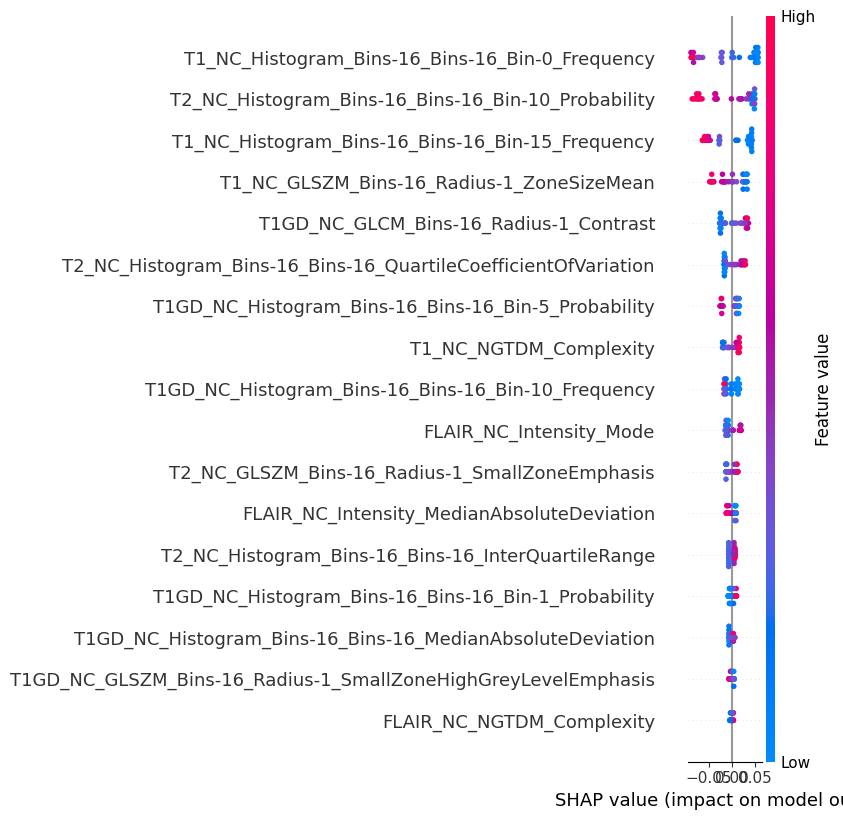

In [ ]:
# Cell: Final GA-RF SHAP (clean version, no warnings)

import numpy as np
import shap
from sklearn.ensemble import RandomForestClassifier

RANDOM_STATE = 42

# 1) GA-selected feature subset from best_ga
ga_cols   = np.asarray(best_ga["cols"], dtype=int)
ga_params = dict(best_ga["best_params"])

Xtr_ga = X_train.iloc[:, ga_cols]
y_tr   = y_train.to_numpy().ravel()

# 2) Fit final RF on full TRAIN with the chosen GA subset
rf_ga_shap = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1,
    **ga_params
)
rf_ga_shap.fit(Xtr_ga, y_tr)

print("[INFO] Final GA-RF model for SHAP trained on full TRAIN.")
print("[INFO] Xtr_ga shape:", Xtr_ga.shape)

# 3) SHAP explainer (tree-based)
explainer = shap.Explainer(
    rf_ga_shap,
    Xtr_ga,            # background = train features
    algorithm="tree",
)

# 4) Compute SHAP values for TRAIN
shap_exp = explainer(Xtr_ga)

vals = shap_exp.values
data = shap_exp.data

print("[INFO] shap_exp.values shape:", vals.shape)
print("[INFO] shap_exp.data   shape:", data.shape)

# 5) For binary RF: pick positive class along the last axis
if vals.ndim == 3:
    vals = vals[:, :, 1]

# 6) Summary plot
shap.summary_plot(
    vals,
    data,
    feature_names=Xtr_ga.columns,
    show=True
)


In [ ]:
# Print the feature names used for SHAP (i.e., the GA-selected subset)
print(f"\n[INFO] SHAP features used (total={Xtr_ga.shape[1]}):")
for i, name in enumerate(Xtr_ga.columns, 1):
    print(f"{i:02d}. {name}")

# (Optional) Print as a single Python list for easy copy/paste
print("\n[INFO] Feature list:")
print(list(Xtr_ga.columns))



[INFO] SHAP features used (total=17):
01. FLAIR_NC_Intensity_MedianAbsoluteDeviation
02. FLAIR_NC_Intensity_Mode
03. FLAIR_NC_NGTDM_Complexity
04. T1_NC_Histogram_Bins-16_Bins-16_Bin-0_Frequency
05. T1_NC_Histogram_Bins-16_Bins-16_Bin-15_Frequency
06. T1_NC_GLSZM_Bins-16_Radius-1_ZoneSizeMean
07. T1_NC_NGTDM_Complexity
08. T1GD_NC_Histogram_Bins-16_Bins-16_Bin-10_Frequency
09. T1GD_NC_Histogram_Bins-16_Bins-16_Bin-1_Probability
10. T1GD_NC_Histogram_Bins-16_Bins-16_Bin-5_Probability
11. T1GD_NC_Histogram_Bins-16_Bins-16_MedianAbsoluteDeviation
12. T1GD_NC_GLCM_Bins-16_Radius-1_Contrast
13. T1GD_NC_GLSZM_Bins-16_Radius-1_SmallZoneHighGreyLevelEmphasis
14. T2_NC_Histogram_Bins-16_Bins-16_Bin-10_Probability
15. T2_NC_Histogram_Bins-16_Bins-16_InterQuartileRange
16. T2_NC_Histogram_Bins-16_Bins-16_QuartileCoefficientOfVariation
17. T2_NC_GLSZM_Bins-16_Radius-1_SmallZoneEmphasis

[INFO] Feature list:
['FLAIR_NC_Intensity_MedianAbsoluteDeviation', 'FLAIR_NC_Intensity_Mode', 'FLAIR_NC_NGTDM_

In [ ]:
# Cell: build t-SNE embedding on GA-selected feature subset (train + test)

from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Cell: build t-SNE embedding on GA-selected feature subset (train + test)

RANDOM_STATE = 42

# 1) Use GA-selected feature indices from best_ga
ga_cols = np.asarray(best_ga["cols"], dtype=int)

# 2) Subset train / test features using the same GA subset
Xtr_ga = X_train.iloc[:, ga_cols]
Xte_ga = X_test.iloc[:, ga_cols]

# 3) Stack train + test into a single matrix for a joint t-SNE embedding
X_all_ga = np.vstack([Xtr_ga.to_numpy(), Xte_ga.to_numpy()])

# y_np, y_te are assumed to be defined earlier as 1D numpy arrays
y_all = np.concatenate([y_np, y_te])

# Indicator for train vs test (for plotting)
split_label = np.array(["train"] * len(y_np) + ["test"] * len(y_te))

print("[INFO] X_all_ga shape:", X_all_ga.shape)
print("[INFO] y_all length:", len(y_all))

# 4) Standardize features before running t-SNE
scaler = StandardScaler()
X_all_ga_scaled = scaler.fit_transform(X_all_ga)

# 5) Run t-SNE in 2D on GA-selected features
tsne = TSNE(
    n_components=2,
    perplexity=20,
    learning_rate="auto",
    init="random",
    n_iter=1000,
    random_state=RANDOM_STATE,
    verbose=1,
)
X_all_tsne = tsne.fit_transform(X_all_ga_scaled)

print("[INFO] t-SNE embedding shape:", X_all_tsne.shape)

# 6) Pack into a DataFrame for convenient plotting
tsne_df = pd.DataFrame({
    "tsne1": X_all_tsne[:, 0],
    "tsne2": X_all_tsne[:, 1],
    "label": y_all,
    "split": split_label,
})


[INFO] X_all_ga shape: (59, 17)
[INFO] y_all length: 59
[t-SNE] Computing 58 nearest neighbors...
[t-SNE] Indexed 59 samples in 0.000s...


c:\Users\junse\miniconda3\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] Computed neighbors for 59 samples in 0.245s...
[t-SNE] Computed conditional probabilities for sample 59 / 59
[t-SNE] Mean sigma: 2.241035
[t-SNE] KL divergence after 250 iterations with early exaggeration: 55.344395
[t-SNE] KL divergence after 800 iterations: 0.446765
[INFO] t-SNE embedding shape: (59, 2)


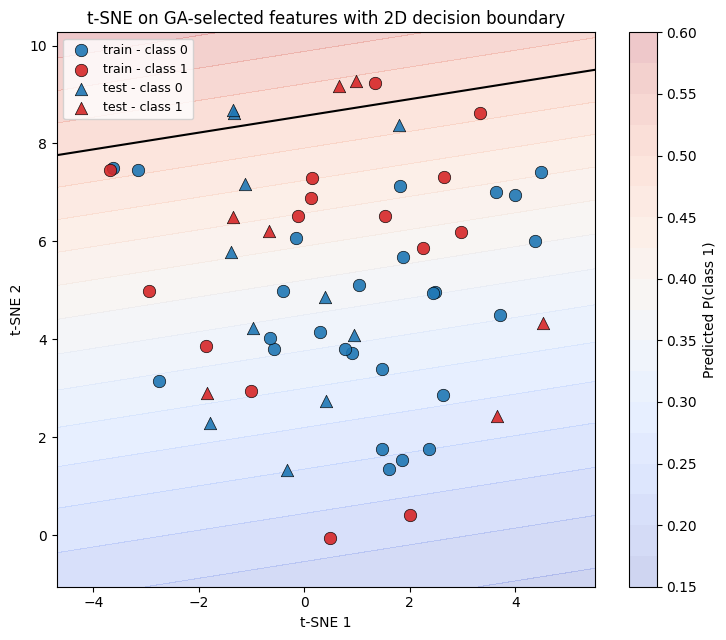

In [ ]:
# Cell: t-SNE + decision boundary (color = class, marker = split)

# -----------------------------
# 1) Train a simple classifier on t-SNE space
# -----------------------------
X_tsne = tsne_df[["tsne1", "tsne2"]].to_numpy()
y_tsne = tsne_df["label"].to_numpy()

clf_2d = LogisticRegression(random_state=42)
clf_2d.fit(X_tsne, y_tsne)

# -----------------------------
# 2) Make a grid over t-SNE space and get P(class=1)
# -----------------------------
x_min, x_max = tsne_df["tsne1"].min() - 1.0, tsne_df["tsne1"].max() + 1.0
y_min, y_max = tsne_df["tsne2"].min() - 1.0, tsne_df["tsne2"].max() + 1.0

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300),
)

grid_points = np.c_[xx.ravel(), yy.ravel()]
proba_grid = clf_2d.predict_proba(grid_points)[:, 1]  # P(y=1)
proba_grid = proba_grid.reshape(xx.shape)

# -----------------------------
# 3) Plot decision surface + contour + points
# -----------------------------
plt.figure(figsize=(7.5, 6.5))

# (a) background: probability of class 1
cs = plt.contourf(
    xx, yy, proba_grid,
    levels=20,
    cmap="coolwarm",
    alpha=0.25,
)
cbar = plt.colorbar(cs)
cbar.set_label("Predicted P(class 1)")

# (b) decision boundary at P=0.5
plt.contour(
    xx, yy, proba_grid,
    levels=[0.5],
    colors="k",
    linewidths=1.5,
)

# (c) overlay the original points (color = class, marker = split)
colors = {0: "tab:blue", 1: "tab:red"}

for split, marker in [("train", "o"), ("test", "^")]:
    df_sub = tsne_df[tsne_df["split"] == split]
    for cls in sorted(df_sub["label"].unique()):
        mask = df_sub["label"] == cls
        if not np.any(mask):
            continue

        plt.scatter(
            df_sub.loc[mask, "tsne1"],
            df_sub.loc[mask, "tsne2"],
            s=80,
            alpha=0.9,
            marker=marker,
            color=colors.get(cls, "gray"),
            edgecolor="k",
            linewidths=0.5,
            label=f"{split} - class {cls}",
        )

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE on GA-selected features with 2D decision boundary")
plt.legend(loc="best", fontsize=9)
plt.tight_layout()
plt.show()


[INFO] Majority-vote features: >= 3/5 GA subsets
[INFO] n_features = 15
[CV] GA-majority (k>=3/5) best AUC = 0.8444
[CV] GA-majority (k>=3/5) best params = {'bootstrap': True, 'class_weight': None, 'criterion': 'gini', 'max_depth': 12, 'max_features': 'sqrt', 'max_samples': None, 'min_samples_leaf': 7, 'min_samples_split': 11, 'n_estimators': 159}

===== TRAIN (5-fold CV, fixed tuned params) =====
Best CV AUC from tuning (rs.best_score_) : 0.8444
CV AUC (mean ± std)                     : 0.7978 ± 0.1576
CV Sensitivity@0.5 (mean ± std)         : 0.2000 ± 0.1826


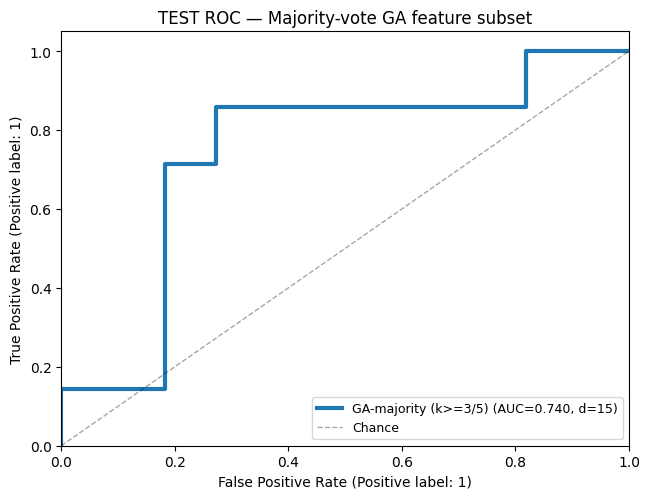


===== SUMMARY: Majority-vote GA subset (CV & TEST) =====
n_features  : 15
TEST AUC    : 0.7403


In [ ]:
# Cell: Majority-vote (>=3 of 5 GA subsets) -> tune RF -> train(CV) AUC/sensitivity -> test ROC

# -----------------------------
# 0) Majority-vote feature subset from GA top-5 (>=3/5)
# -----------------------------
ga5 = [fs for fs in feature_sets if fs["name"].startswith("GA-")]
if len(ga5) < 5:
    raise ValueError(f"Need 5 GA subsets in feature_sets. Found {len(ga5)}.")
ga5 = ga5[:5]

n_feat_total = X_train.shape[1]
cnt = np.zeros(n_feat_total, dtype=int)
for fs in ga5:
    cols = np.asarray(fs["cols"], dtype=int)
    cnt[cols] += 1

MAJ_K = 3
maj_cols = np.where(cnt >= MAJ_K)[0]
if len(maj_cols) == 0:
    raise ValueError(f"No features appear in >= {MAJ_K} of the 5 GA subsets.")

print(f"[INFO] Majority-vote features: >= {MAJ_K}/5 GA subsets")
print(f"[INFO] n_features = {len(maj_cols)}")

# -----------------------------
# 1) Tune RF on TRAIN using your existing tuning function
# -----------------------------
maj_label = f"GA-majority (k>={MAJ_K}/5)"
maj_best_params, maj_cv_best = tune_rf_for_features(maj_cols, maj_label)

# -----------------------------
# 2) Train metrics via 5-fold CV (fixed best_params): AUC + sensitivity@0.5
# -----------------------------
Xtr = X_train.iloc[:, maj_cols].to_numpy()
ytr = y_np

auc_folds  = []
sens_folds = []

for tr_idx, va_idx in cv5.split(Xtr, ytr):
    X_tr, X_va = Xtr[tr_idx], Xtr[va_idx]
    y_tr, y_va = ytr[tr_idx], ytr[va_idx]

    clf = RandomForestClassifier(
        random_state=2026,
        n_jobs=-1,
        **maj_best_params
    )
    clf.fit(X_tr, y_tr)

    prob_va = clf.predict_proba(X_va)[:, 1]
    auc_va  = roc_auc_score(y_va, prob_va)

    pred_va = (prob_va >= 0.5).astype(int)
    pos = (y_va == 1)
    sens_va = ((pred_va == 1) & pos).sum() / max(pos.sum(), 1)

    auc_folds.append(auc_va)
    sens_folds.append(sens_va)

cv_auc_mean  = float(np.mean(auc_folds))
cv_auc_std   = float(np.std(auc_folds, ddof=1)) if len(auc_folds) > 1 else 0.0
cv_sens_mean = float(np.mean(sens_folds))
cv_sens_std  = float(np.std(sens_folds, ddof=1)) if len(sens_folds) > 1 else 0.0

print("\n===== TRAIN (5-fold CV, fixed tuned params) =====")
print(f"Best CV AUC from tuning (rs.best_score_) : {maj_cv_best:.4f}")
print(f"CV AUC (mean ± std)                     : {cv_auc_mean:.4f} ± {cv_auc_std:.4f}")
print(f"CV Sensitivity@0.5 (mean ± std)         : {cv_sens_mean:.4f} ± {cv_sens_std:.4f}")

# -----------------------------
# 3) Fit on FULL TRAIN, evaluate on TEST, plot TEST ROC
# -----------------------------
Xte = X_test.iloc[:, maj_cols].to_numpy()

final_clf = RandomForestClassifier(
    random_state=2042,
    n_jobs=-1,
    **maj_best_params
)
final_clf.fit(Xtr, ytr)

prob_te = final_clf.predict_proba(Xte)[:, 1]
test_auc = float(roc_auc_score(y_te, prob_te))
fpr, tpr, _ = roc_curve(y_te, prob_te)

plt.figure(figsize=(6.6, 5.1))
plt.plot(
    fpr, tpr,
    lw=3.0,
    label=f"{maj_label} (AUC={test_auc:.3f}, d={len(maj_cols)})"
)
plt.plot([0, 1], [0, 1], "--", lw=1, color="black", alpha=0.35, label="Chance")
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.xlabel("False Positive Rate (Positive label: 1)")
plt.ylabel("True Positive Rate (Positive label: 1)")
plt.title("TEST ROC — Majority-vote GA feature subset")
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

print("\n===== SUMMARY: Majority-vote GA subset (CV & TEST) =====")
print(f"n_features  : {len(maj_cols)}")
print(f"TEST AUC    : {test_auc:.4f}")


[INFO] Final RF trained for SHAP.
[INFO] Xtr_maj shape: (41, 15)
[INFO] shap_exp.values shape: (41, 15, 2)
[INFO] shap_exp.data   shape: (41, 15)


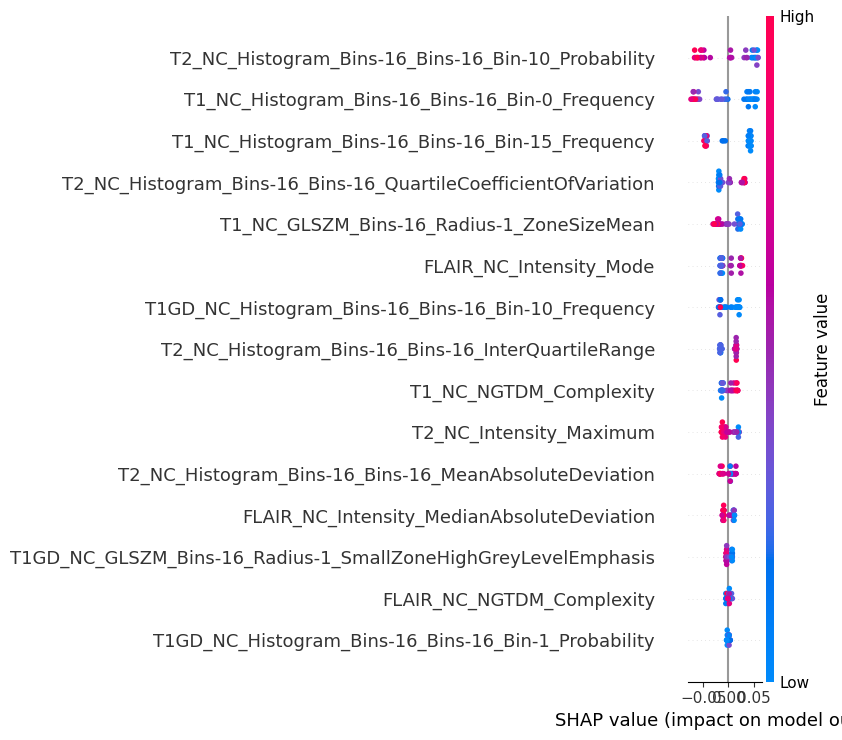

In [ ]:
# Cell: SHAP for Majority-vote GA-RF (train only)

# 1) Use majority-vote feature subset + tuned params
maj_cols   = np.asarray(maj_cols, dtype=int)
maj_params = dict(maj_best_params)

Xtr_maj = X_train.iloc[:, maj_cols]
y_tr    = y_train.to_numpy().ravel()

# 2) Fit final RF on full TRAIN
rf_maj_shap = RandomForestClassifier(
    random_state=2042,
    n_jobs=-1,
    **maj_params
)
rf_maj_shap.fit(Xtr_maj, y_tr)

print("[INFO] Final RF trained for SHAP.")
print("[INFO] Xtr_maj shape:", Xtr_maj.shape)

# 3) SHAP explainer (tree-based)
explainer = shap.Explainer(
    rf_maj_shap,
    Xtr_maj,
    algorithm="tree",
)

# 4) Compute SHAP values on TRAIN
shap_exp = explainer(Xtr_maj)

vals = shap_exp.values
data = shap_exp.data

print("[INFO] shap_exp.values shape:", vals.shape)
print("[INFO] shap_exp.data   shape:", data.shape)

# 5) For binary RF: pick positive class along the last axis
if vals.ndim == 3:
    vals = vals[:, :, 1]

# 6) Summary plot (top 15)
shap.summary_plot(
    vals,
    data,
    feature_names=Xtr_maj.columns,
    max_display=15,
    show=True
)


In [ ]:
# Get the feature names for the majority-vote subset
maj_feature_names = X_train.columns[maj_cols]

print(f"\n[INFO] SHAP features used (total={len(maj_feature_names)}):")
for i, name in enumerate(maj_feature_names, 1):
    print(f"{i:02d}. {name}")

# (Optional) Print as a single Python list for easy copy/paste
print("\n[INFO] Feature list:")
print(list(maj_feature_names))



[INFO] SHAP features used (total=15):
01. FLAIR_NC_Intensity_MedianAbsoluteDeviation
02. FLAIR_NC_Intensity_Mode
03. FLAIR_NC_NGTDM_Complexity
04. T1_NC_Histogram_Bins-16_Bins-16_Bin-0_Frequency
05. T1_NC_Histogram_Bins-16_Bins-16_Bin-15_Frequency
06. T1_NC_GLSZM_Bins-16_Radius-1_ZoneSizeMean
07. T1_NC_NGTDM_Complexity
08. T1GD_NC_Histogram_Bins-16_Bins-16_Bin-10_Frequency
09. T1GD_NC_Histogram_Bins-16_Bins-16_Bin-1_Probability
10. T1GD_NC_GLSZM_Bins-16_Radius-1_SmallZoneHighGreyLevelEmphasis
11. T2_NC_Intensity_Maximum
12. T2_NC_Histogram_Bins-16_Bins-16_Bin-10_Probability
13. T2_NC_Histogram_Bins-16_Bins-16_InterQuartileRange
14. T2_NC_Histogram_Bins-16_Bins-16_MeanAbsoluteDeviation
15. T2_NC_Histogram_Bins-16_Bins-16_QuartileCoefficientOfVariation

[INFO] Feature list:
['FLAIR_NC_Intensity_MedianAbsoluteDeviation', 'FLAIR_NC_Intensity_Mode', 'FLAIR_NC_NGTDM_Complexity', 'T1_NC_Histogram_Bins-16_Bins-16_Bin-0_Frequency', 'T1_NC_Histogram_Bins-16_Bins-16_Bin-15_Frequency', 'T1_NC_GLS

Permutation importance identified a small set of features whose permutation caused the largest drop in training ROC AUC, suggesting these features contribute most strongly to the model’s predictive performance.


===== Permutation Importance (TRAIN, ROC AUC drop) =====


,feature,perm_importance_mean,perm_importance_std
11,T2_NC_Histogram_Bins-16_Bins-16_Bin-10_Probabi...,0.050897,0.021195
3,T1_NC_Histogram_Bins-16_Bins-16_Bin-0_Frequency,0.048462,0.016655
4,T1_NC_Histogram_Bins-16_Bins-16_Bin-15_Frequency,0.027949,0.014548
12,T2_NC_Histogram_Bins-16_Bins-16_InterQuartileR...,0.017051,0.005974
14,T2_NC_Histogram_Bins-16_Bins-16_QuartileCoeffi...,0.009487,0.005005
1,FLAIR_NC_Intensity_Mode,0.008974,0.006041
10,T2_NC_Intensity_Maximum,0.006538,0.006357
7,T1GD_NC_Histogram_Bins-16_Bins-16_Bin-10_Frequ...,0.005897,0.006441
5,T1_NC_GLSZM_Bins-16_Radius-1_ZoneSizeMean,0.004872,0.006532
2,FLAIR_NC_NGTDM_Complexity,0.003590,0.001701


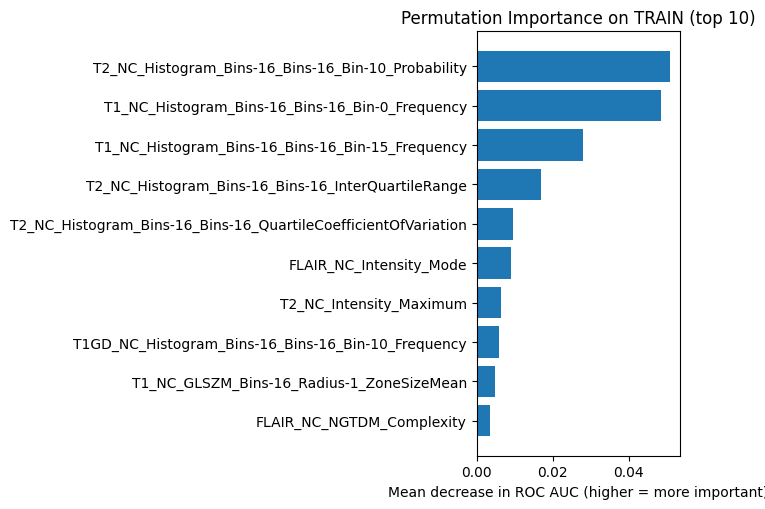

In [ ]:
# Cell: Permutation Importance on TRAIN (ROC AUC drop) — use for interpretation

from sklearn.inspection import permutation_importance

# 0) Train final RF on FULL TRAIN (same params as evaluation)
Xtr_maj = X_train.iloc[:, maj_cols].to_numpy()
ytr     = y_np

rf = RandomForestClassifier(
    random_state=2042,
    n_jobs=-1,
    **maj_best_params
)
rf.fit(Xtr_maj, ytr)

feat_names = X_train.columns[maj_cols]

# 1) Permutation importance on TRAIN (AUC drop)
perm = permutation_importance(
    rf,
    Xtr_maj, ytr,
    scoring="roc_auc",
    n_repeats=20,
    random_state=2042,
    n_jobs=-1
)

imp_df = pd.DataFrame({
    "feature": feat_names,
    "perm_importance_mean": perm.importances_mean,
    "perm_importance_std":  perm.importances_std,
}).sort_values("perm_importance_mean", ascending=False)

print("\n===== Permutation Importance (TRAIN, ROC AUC drop) =====")
display(imp_df.head(15))

topk = 10
plot_df = imp_df.head(topk).iloc[::-1]
plt.figure(figsize=(7.0, 5.2))
plt.barh(plot_df["feature"], plot_df["perm_importance_mean"])
plt.xlabel("Mean decrease in ROC AUC (higher = more important)")
plt.title(f"Permutation Importance on TRAIN (top {topk})")
plt.tight_layout()
plt.show()


In [ ]:
# Cell: Report baseline TRAIN/TEST AUC + show AUC after permuting top features (TRAIN + TEST)

rng = np.random.default_rng(2042)

# 0) Baseline AUC on TRAIN and TEST (using the same trained rf)
prob_tr = rf.predict_proba(Xtr_maj)[:, 1]
train_auc = float(roc_auc_score(ytr, prob_tr))

Xte_maj = X_test.iloc[:, maj_cols].to_numpy()
prob_te = rf.predict_proba(Xte_maj)[:, 1]
test_auc = float(roc_auc_score(y_te, prob_te))

print("\n===== Baseline performance (same fitted model) =====")
print(f"TRAIN AUC: {train_auc:.4f}")
print(f"TEST  AUC: {test_auc:.4f}")

# 1) AUC after permuting each top feature once (single run) on TRAIN and TEST
TOPM = 5
top_features = imp_df["feature"].head(TOPM).tolist()
name_to_j = {name: j for j, name in enumerate(feat_names)}

print(f"\n===== AUC after permuting top {TOPM} features on TRAIN (single shuffle each) =====")
for name in top_features:
    j = name_to_j[name]

    Xtr_perm = Xtr_maj.copy()
    Xtr_perm[:, j] = np.random.permutation(Xtr_perm[:, j])

    prob_perm = rf.predict_proba(Xtr_perm)[:, 1]
    auc_perm  = float(roc_auc_score(ytr, prob_perm))

    print(f"{name}: TRAIN AUC {auc_perm:.4f}  (drop {train_auc - auc_perm:+.4f})")

print(f"\n===== AUC after permuting top {TOPM} features on TEST (single shuffle each) =====")
for name in top_features:
    j = name_to_j[name]

    Xte_perm = Xte_maj.copy()
    Xte_perm[:, j] = np.random.permutation(Xte_perm[:, j])

    prob_perm = rf.predict_proba(Xte_perm)[:, 1]
    auc_perm  = float(roc_auc_score(y_te, prob_perm))

    print(f"{name}: TEST  AUC {auc_perm:.4f}  (drop {test_auc - auc_perm:+.4f})")



===== Baseline performance (same fitted model) =====
TRAIN AUC: 0.9872
TEST  AUC: 0.7403

===== AUC after permuting top 5 features on TRAIN (single shuffle each) =====
T2_NC_Histogram_Bins-16_Bins-16_Bin-10_Probability: TRAIN AUC 0.9436  (drop +0.0436)
T1_NC_Histogram_Bins-16_Bins-16_Bin-0_Frequency: TRAIN AUC 0.8949  (drop +0.0923)
T1_NC_Histogram_Bins-16_Bins-16_Bin-15_Frequency: TRAIN AUC 0.9641  (drop +0.0231)
T2_NC_Histogram_Bins-16_Bins-16_InterQuartileRange: TRAIN AUC 0.9718  (drop +0.0154)
T2_NC_Histogram_Bins-16_Bins-16_QuartileCoefficientOfVariation: TRAIN AUC 0.9846  (drop +0.0026)

===== AUC after permuting top 5 features on TEST (single shuffle each) =====
T2_NC_Histogram_Bins-16_Bins-16_Bin-10_Probability: TEST  AUC 0.6753  (drop +0.0649)
T1_NC_Histogram_Bins-16_Bins-16_Bin-0_Frequency: TEST  AUC 0.6883  (drop +0.0519)
T1_NC_Histogram_Bins-16_Bins-16_Bin-15_Frequency: TEST  AUC 0.7792  (drop -0.0390)
T2_NC_Histogram_Bins-16_Bins-16_InterQuartileRange: TEST  AUC 0.7662  (